In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import BaggingClassifier

In [5]:
heart_data = pd.read_csv("datasets/heart.csv")
heart = heart_data.copy()

In [6]:
heart.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1,1
295,63,1,0,140,187,0,0,144,1,4.0,2,2,3,0
107,45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
215,43,0,0,132,341,1,0,136,1,3.0,1,0,3,0
253,67,1,0,100,299,0,0,125,1,0.9,1,2,2,0


In [7]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [8]:
heart.duplicated().sum()

np.int64(1)

In [9]:
# remove duplicates
heart = heart.drop_duplicates()

In [10]:
heart["target"].unique()

array([1, 0])

In [11]:
X = heart.drop(columns=["target"], axis=1)
y = heart["target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
y_train[y_train == 1].size # 132
y_train[y_train == 0].size # 109
y_test[y_test == 1].size # 32
y_test[y_test == 0].size # 29
# good balance of two categories

29

In [14]:
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# X_train

In [15]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [16]:
y_test_predicted = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_test_predicted)
precision = precision_score(y_test, y_test_predicted)
recall = recall_score(y_test, y_test_predicted)
f1 = f1_score(y_test, y_test_predicted)
print("Accuracy score:", accuracy)
print("Precision socre:", precision)
print("Recall score:", recall)
print("F1 score:", f1)

Accuracy score: 0.819672131147541
Precision socre: 0.8387096774193549
Recall score: 0.8125
F1 score: 0.8253968253968254


In [18]:
cf = confusion_matrix(y_test, y_test_predicted)
print(cf)

[[24  5]
 [ 6 26]]


In [19]:
print(classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [20]:
y_train_predicted = model.predict(X_train)
accuracy = accuracy_score(y_train, y_train_predicted)
precision = precision_score(y_train, y_train_predicted)
recall = recall_score(y_train, y_train_predicted)
f1 = f1_score(y_test, y_test_predicted)
print("Accuracy score:", accuracy)
print("Precision socre:", precision)
print("Recall score:", recall)
print("F1 score:", f1)

Accuracy score: 0.8672199170124482
Precision socre: 0.8571428571428571
Recall score: 0.9090909090909091
F1 score: 0.8253968253968254


In [21]:
# Bagging Regressor 
br_model = BaggingClassifier(
    LogisticRegression(max_iter=10000),
    n_estimators=201,
    oob_score=True,
)

br_model.fit(X_train, y_train)

,estimator,LogisticRegre...ax_iter=10000)
,n_estimators,201
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [22]:
y_train_predicted = model.predict(X_train)
accuracy = accuracy_score(y_train, y_train_predicted)
precision = precision_score(y_train, y_train_predicted)
recall = recall_score(y_train, y_train_predicted)
f1 = f1_score(y_test, y_test_predicted)
print("Accuracy score:", accuracy)
print("OOB score:", br_model.oob_score_)
print("Precision socre:", precision)
print("Recall score:", recall)
print("F1 score:", f1)

Accuracy score: 0.8672199170124482
OOB score: 0.8381742738589212
Precision socre: 0.8571428571428571
Recall score: 0.9090909090909091
F1 score: 0.8253968253968254


Text(0, 0.5, 'True positive rate')

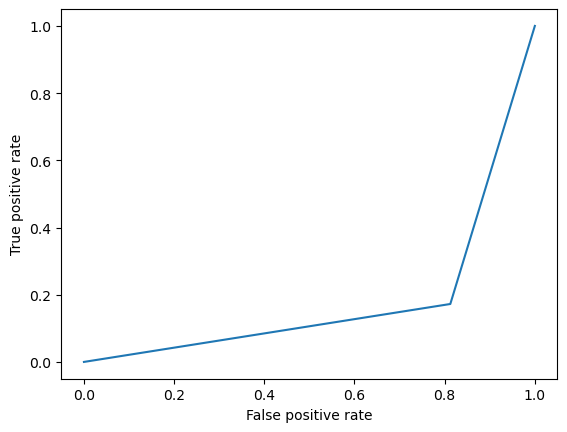

In [23]:
tpr, fpr, thresholds = roc_curve(y_test, y_test_predicted)

plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

Text(0, 0.5, 'Precision')

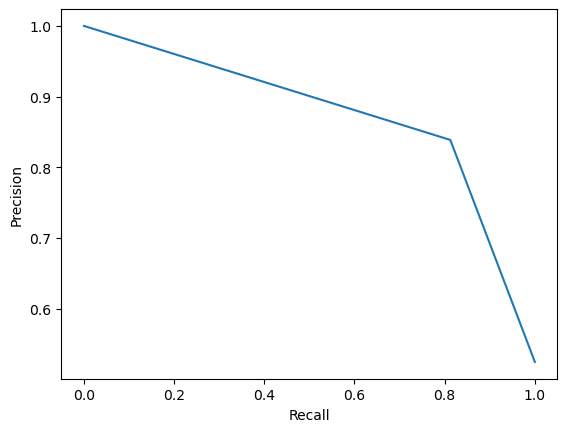

In [25]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_predicted)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")

In [29]:
for i in range(len(thresholds)):
    print("Precision: ", precision[i], "Recall: ", recall[i], "Threshold: ", thresholds[i])

Precision:  0.5245901639344263 Recall:  1.0 Threshold:  0
Precision:  0.8387096774193549 Recall:  0.8125 Threshold:  1


In [31]:
print(auc(fpr, tpr))

0.17995689655172414
